# 2、正规方程

## 2.1、最小二乘法

最小二乘法(Least Squares Method)是一种常见的数学优化技术，用于拟合一组数据点的最佳线性回归方程。

它的目标是找到一条直线，使得该直线与数据点之间的误差平方和最小。

具体而言，最小二乘法的目标是最小化每个数据点与拟合直线之间的垂直距离的平方和，即最小化所有数据点到拟合直线的残差平方和，残差是指每个数据点的实际值与拟合直线在该点处的预测值之间的差异。

最小二乘法可用于回归分析，即对一组数据进行拟合，并预测未来数据点的值。

此外，它还可以用于求解线性方程组，如线性回归模型的系数或参数估计等最小二乘法可以将误差方程转化为有确定解的代数方程组(其方程式数目正好等于未知数的个数)，从而可求解出这些未知参数。

这个有确定解的代数方程组称为最小二乘法估计的正规方程，公式如下:

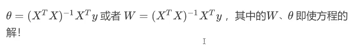

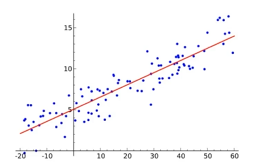

公式是如何推导的？

最小二乘法公式如下：

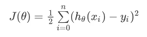

使用矩阵表示：

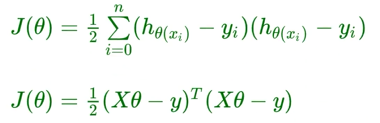

之所以要使用转置T，是因为，矩阵运算规律是:矩阵A的一行乘以矩阵B的一列!

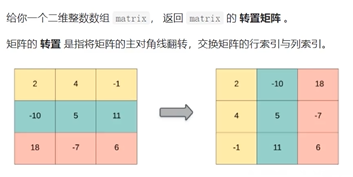

## 2.2、多元一次方程举例

1. 二元一次方程

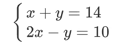

2. 三元一次方程

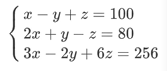

3. 八元一次方程

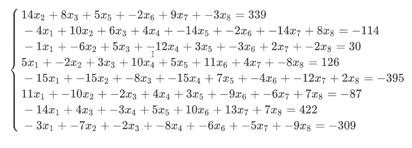

### 2.2.1、正规方程求解多元一次方程

$$\begin{cases}
x + y = 14 \\
2x - y = 10
\end{cases}$$

$$w = (X^T X)^{-1} X^T y$$

In [2]:
import numpy as np

In [3]:
X = np.array([[1, 1], [2, -1]])
X

array([[ 1,  1],
       [ 2, -1]])

In [4]:
y = np.array([14, 10])
y

array([14, 10])

In [6]:
np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

array([8., 6.])

$$f(x) = 8x_1 + 6x_2$$

In [7]:
8 * 1 + 6 * 1

14

### 2.2.2、三元一次方程

$$\begin{cases}
x - y + z = 100 \\
2x + y - z = 80 \\
3x - 2y + 6z = 256
\end{cases}$$

In [8]:
X = np.array([[1, -1, 1], [2, 1, -1], [3, -2, 6]])
y = np.array([100, 80, 256])
display(X, y)

array([[ 1, -1,  1],
       [ 2,  1, -1],
       [ 3, -2,  6]])

array([100,  80, 256])

In [9]:
np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

array([ 60., -41.,  -1.])

### 2.2.3、八元一次方程

$$\begin{cases}
14x_2 + 8x_3 + 5x_5 - 2x_6 + 9x_7 - 3x_8 = 339 \\
- 4x_1 + 10x_2 + 6x_3 + 4x_4 - 14x_5 - 2x_6 - 14x_7 + 8x_8 = -114 \\
- 1x_1 - 6x_2 + 5x_3 - 12x_4 + 3x_5 - 3x_6 + 2x_7 - 2x_8 = 30 \\
5x_1 - 2x_2 + 3x_3 + 10x_4 + 5x_5 + 11x_6 + 4x_7 - 8x_8 = 126 \\
- 15x_1 - 15x_2 - 8x_3 - 15x_4 + 7x_5 - 4x_6 - 12x_7 + 2x_8 = -395 \\
11x_1 - 10x_2 - 2x_3 + 4x_4 + 3x_5 - 9x_6 - 6x_7 + 7x_8 = -87 \\
- 14x_1 + 4x_3 - 3x_4 + 5x_5 + 10x_6 + 13x_7 + 7x_8 = 422 \\
- 3x_1 - 7x_2 - 2x_3 - 8x_4 - 6x_6 - 5x_7 - 9x_8 = -309
\end{cases}$$

In [10]:
# 提取系数矩阵 X (注意第一行和第七行中缺失的未知数系数补 0)
X = np.array([
    [  0,  14,   8,   0,   5,  -2,   9,  -3],
    [ -4,  10,   6,   4, -14,  -2, -14,   8],
    [ -1,  -6,   5, -12,   3,  -3,   2,  -2],
    [  5,  -2,   3,  10,   5,  11,   4,  -8],
    [-15, -15,  -8, -15,   7,  -4, -12,   2],
    [ 11, -10,  -2,   4,   3,  -9,  -6,   7],
    [-14,   0,   4,  -3,   5,  10,  13,   7],
    [ -3,  -7,  -2,  -8,   0,  -6,  -5,  -9]
])

# 提取常数项向量 y
y = np.array([339, -114, 30, 126, -395, -87, 422, -309])

# 使用你之前图中的正规方程公式求解
w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
print(w)

[ 1.  5. 15.  3.  8.  4. 17. 12.]


## 2.3、矩阵转置公式与求导公式

转置公式如下：

* $(mA)^T = m A^T$，其中 $m$ 是常数
* $(A + B)^T = A^T + B^T$
* $(AB)^T = B^T A^T$
* $(A^T)^T = A$

求导公式如下：
* $\frac{\partial X^T}{\partial X} = I$ 求解出来是单位矩阵
* $\frac{\partial X^T A}{\partial X} = A$
* $\frac{\partial A X^T}{\partial X} = A$
* $\frac{\partial A X}{\partial X} = A^T$
* $\frac{\partial X A}{\partial X} = A^T$
* $\frac{\partial X^T A X}{\partial X} = (A + A^T)X$ ；$A$ 不是对称矩阵
* $\frac{\partial X^T A X}{\partial X} = 2AX$ ；$A$ 是对称矩阵

## 2.4、推导正规方程 $\theta$ 的解

1. 矩阵乘法公式展开

* $J(\theta) = \frac{1}{2}(X\theta - y)^T (X\theta - y)$
* $J(\theta) = \frac{1}{2}(\theta^T X^T - y^T)(X\theta - y)$
* $J(\theta) = \frac{1}{2}(\theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y)$

 2. 进行求导（注意X、y是已知量，$\theta$ 是未知数）：

* $J'(\theta) = \frac{1}{2}(\theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y)'$
  $y^T y$ 是常量
* $J'(\theta) = \frac{1}{2}((\theta^T X^T X \theta)' - (\theta^T X^T y)' - (y^T X \theta)')$

根据2.3、矩阵转置公式与求导公式可知

* $J'(\theta) = \frac{1}{2}((\theta^T X^T X \theta)' - X^T y - (y^T X)^T)$
* $J'(\theta) = \frac{1}{2}(X^T X \theta + (\theta^T X^T X)^T - X^T y - (y^T X)^T)$
* $J'(\theta) = \frac{1}{2}(X^T X \theta + X^T X \theta - X^T y - X^T y)$

3. 根据上面求导公式进行运算：

* $J'(\theta) = \frac{1}{2}(X^T X \theta + (\theta^T X^T X)^T - X^T y - (y^T X)^T)$
* $J'(\theta) = \frac{1}{2}(X^T X \theta + X^T X \theta - X^T y - X^T y)$
* $J'(\theta) = \frac{1}{2}(2X^T X \theta - 2X^T y)$
* $J'(\theta) = X^T X \theta - X^T y$
* $J'(\theta) = X^T (X \theta - y)$ 矩阵运算分配律

4. 令导数 $J'(\theta) = 0$：

* $0 = X^T X \theta - X^T y$
* $X^T X \theta = X^T y$

5. 矩阵没有除法，使用逆矩阵进行转化：

* $(X^T X)^{-1} X^T X \theta = (X^T X)^{-1} X^T y$
* $I \theta = (X^T X)^{-1} X^T y$
* $\theta = (X^T X)^{-1} X^T y$

到此为止，公式推导出来了~

## 2.5、凸函数判定

判定损失函数是凸函数的好处在于我们可能很肯定的知道我们求得的极值即最优解，一定是全局最优解。

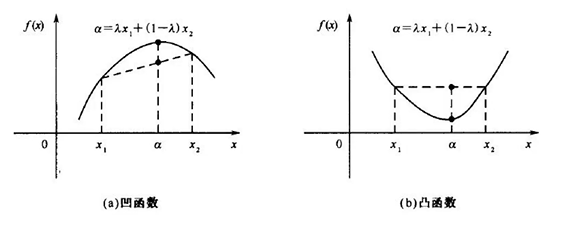

如果是非凸函数，那就不一定可以获取全局最优解~

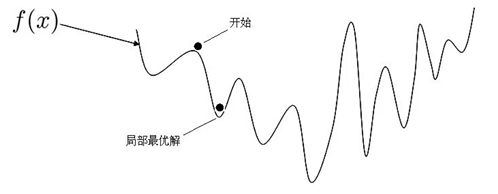

来一个更加立体的效果图：

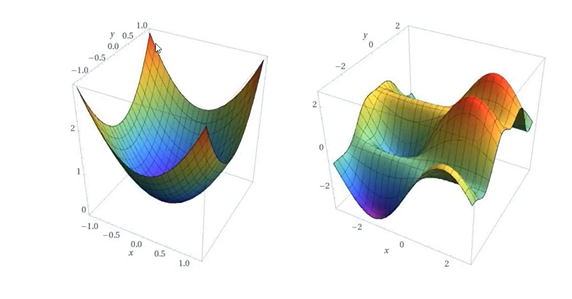

判定凸函数的方式: 判定凸函数的方式非常多，其中一个方法是看黑塞矩阵是否是半正定的。

黑塞矩阵(hessian matrix)是由目标函数在点 $X$ 处的二阶偏导数组成的对称矩阵。

对于我们的式子来说就是在导函数的基础上再次对 $\theta$ 来求偏导，结果就是 $X^T X$。所谓正定就是 $X^T X$ 的特征值全为正数，半正定就是 $X^T X$ 的特征值大于等于 $0$，就是半正定。

$$J'(\theta) = X^T X\theta - X^T y$$
$$J''(\theta) = X^T X$$

这里我们对 $J(\theta)$ 损失函数求二阶导数的黑塞矩阵是 $X^T X$，得到的一定是半正定的，自己和自己做点乘嘛！

当 $X$ 为任意大小的实矩阵时，$X^T X$ 一定是半正定的。

要证明 $X^T X$ 是半正定的，可以考虑对于任意非零向量 $v$，证明 $v^T (X^T X)v$ 非负。注意到 $v^T (X^T X)v = (Xv)^T (Xv) = \|Xv\|^2 \ge 0$，其中 $\|Xv\|$ 表示向量 $Xv$ 的范数，等于 $\sqrt{(Xv)^T (Xv)}$。因此，$X^T X$ 是半正定的。

这里不用数学推导证明这一点。在机器学习中往往损失函数都是**凸函数**，到**深度学习**中损失函数往往是**非凸函数**，即找到的解未必是全局最优，只要模型堪用就好！机器学习特点是：不强调模型 100% 正确，只要是有价值的，堪用的，就 Okay！

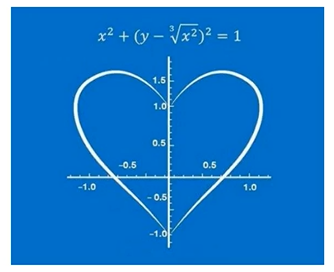